# Indian Food Nutrition

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [73]:
df_indianfood=pd.read_csv("Indian_Food_Nutrition_Processed.csv")
df_indianfood.head()

,Dish Name,Calories (kcal),Carbohydrates (g),Protein (g),Fats (g),Free Sugar (g),Fibre (g),Sodium (mg),Calcium (mg),Iron (mg),Vitamin C (mg),Folate (µg)
0,Hot tea (Garam Chai),16.14,2.58,0.39,0.53,2.58,0.00,3.12,14.20,0.02,0.50,1.80
1,Instant coffee,23.16,3.65,0.64,0.75,3.62,0.00,4.92,20.87,0.06,1.51,5.60
2,Espreso coffee,51.54,6.62,1.75,2.14,6.53,0.00,13.98,58.10,0.15,1.51,5.53
3,Iced tea,10.34,2.70,0.03,0.01,2.70,0.00,0.23,1.18,0.02,5.95,1.28
4,Raw mango drink (Aam panna),35.92,9.05,0.16,0.03,7.49,0.61,79.82,7.08,0.14,45.30,14.05


In [74]:
df_indianfood.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Dish Name          1014 non-null   object 
 1   Calories (kcal)    1014 non-null   float64
 2   Carbohydrates (g)  1014 non-null   float64
 3   Protein (g)        1014 non-null   float64
 4   Fats (g)           1014 non-null   float64
 5   Free Sugar (g)     1014 non-null   float64
 6   Fibre (g)          1014 non-null   float64
 7   Sodium (mg)        1014 non-null   float64
 8   Calcium (mg)       1014 non-null   float64
 9   Iron (mg)          1014 non-null   float64
 10  Vitamin C (mg)     932 non-null    float64
 11  Folate (µg)        932 non-null    float64
dtypes: float64(11), object(1)
memory usage: 95.2+ KB


In [108]:
df_indianfood.describe()

,Calories (kcal),Carbohydrates (g),Protein (g),Fats (g),Free Sugar (g),Fibre (g),Sodium (mg),Calcium (mg),Iron (mg),Vitamin C (mg),Folate (µg)
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,233.735897,18.354004,4.753008,16.267584,8.824832,1.962485,481.076755,59.877091,1.136953,13.773353,38.530020
std,187.599467,16.745936,3.442746,20.452322,12.378324,2.771622,1750.646423,67.441463,1.520863,25.845012,53.154148
min,6.610000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,101.180000,5.582500,2.100000,4.030000,1.152500,0.590000,41.910000,18.237500,0.460000,0.412500,9.252500
50%,174.920000,11.925000,3.990000,9.095000,2.780000,1.325000,101.290000,40.680000,0.830000,4.625000,21.955000
75%,315.845000,26.870000,6.602500,17.085000,11.822500,2.347500,196.605000,79.385000,1.290000,16.667500,45.437500
max,839.330000,86.530000,21.550000,90.450000,85.570000,35.710000,14174.590000,631.820000,20.570000,382.640000,550.520000


## Nettoyage de données

In [75]:
df_indianfood.isna().sum()

Dish Name             0
Calories (kcal)       0
Carbohydrates (g)     0
Protein (g)           0
Fats (g)              0
Free Sugar (g)        0
Fibre (g)             0
Sodium (mg)           0
Calcium (mg)          0
Iron (mg)             0
Vitamin C (mg)       82
Folate (µg)          82
dtype: int64

In [76]:
df_indianfood.isnull().sum()

Dish Name             0
Calories (kcal)       0
Carbohydrates (g)     0
Protein (g)           0
Fats (g)              0
Free Sugar (g)        0
Fibre (g)             0
Sodium (mg)           0
Calcium (mg)          0
Iron (mg)             0
Vitamin C (mg)       82
Folate (µg)          82
dtype: int64

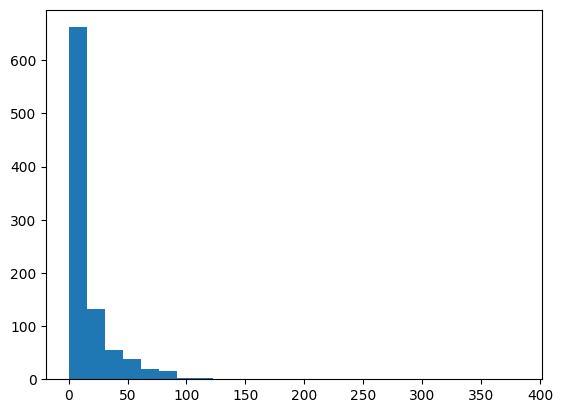

In [77]:
plt.hist(df_indianfood["Vitamin C (mg)"], bins=25)
plt.show()

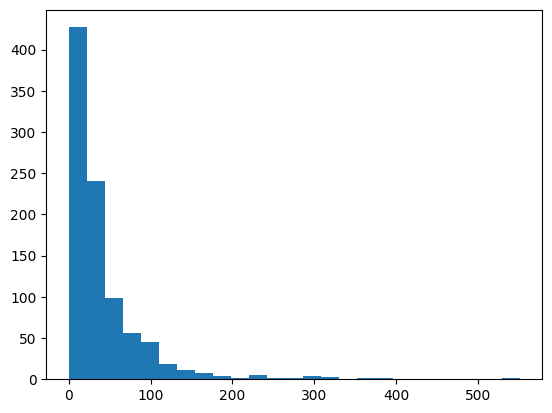

In [78]:
plt.hist(df_indianfood["Folate (µg)"], bins=25)
plt.show()

### Test de Kolmogorov-Smirnov pour tester les données

#### Pour la Vitamine C

In [79]:
import numpy as np
import scipy.stats as st

In [80]:
vec_vitaminC = df_indianfood["Vitamin C (mg)"].dropna()
lambda_param = 1.0 / np.mean(vec_vitaminC)


stat, p_value = st.kstest(vec_vitaminC, 'expon', args=(lambda_param,))
print(f"Test d'Exponentielle: Statistique = {stat}, p-value = {p_value}")

Test d'Exponentielle: Statistique = 0.5808782381697132, p-value = 4.6826429645113693e-299


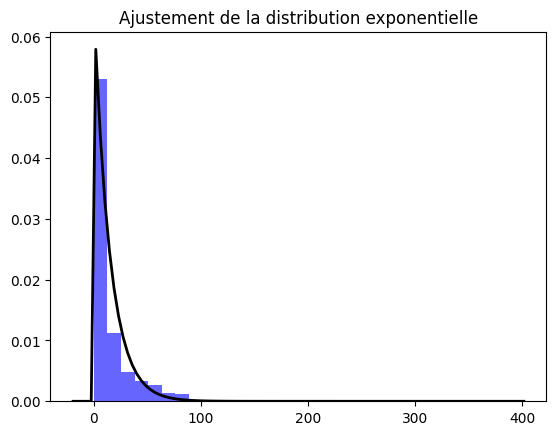

In [81]:
plt.hist(vec_vitaminC, bins=30, density=True, alpha=0.6, color='b')
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = st.expon.pdf(x, scale=1/lambda_param)
plt.plot(x, p, 'k', linewidth=2)
plt.title('Ajustement de la distribution exponentielle')
plt.show()

In [82]:
shape, loc, scale = st.gamma.fit(vec_vitaminC)

stat, p_value = st.kstest(vec_vitaminC, 'gamma', args=(shape, loc, scale))
print(f"Test de Gamma: Statistique = {stat}, p-value = {p_value}")

Test de Gamma: Statistique = 0.7540438828035307, p-value = 0.0


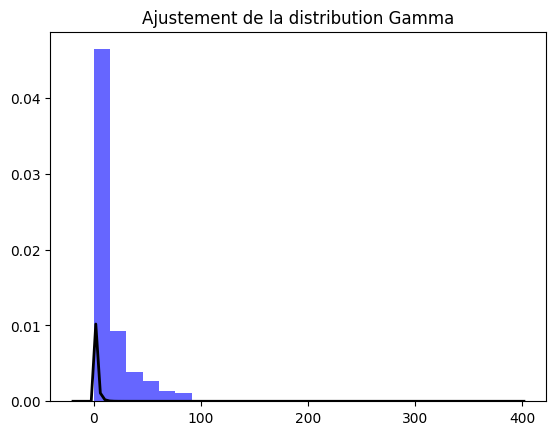

In [83]:
plt.hist(vec_vitaminC, bins=25, density=True, alpha=0.6, color='b')
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = st.gamma.pdf(x, shape, loc=loc, scale=scale)
plt.plot(x, p, 'k', linewidth=2)
plt.title('Ajustement de la distribution Gamma')
plt.show()

In [84]:
shape, loc, scale = st.weibull_min.fit(vec_vitaminC)

stat, p_value = st.kstest(vec_vitaminC, 'weibull_min', args=(shape, loc, scale))
print(f"Test de Weibull: Statistique = {stat}, p-value = {p_value}")

Test de Weibull: Statistique = 0.10482662300153156, p-value = 2.266203248512362e-09


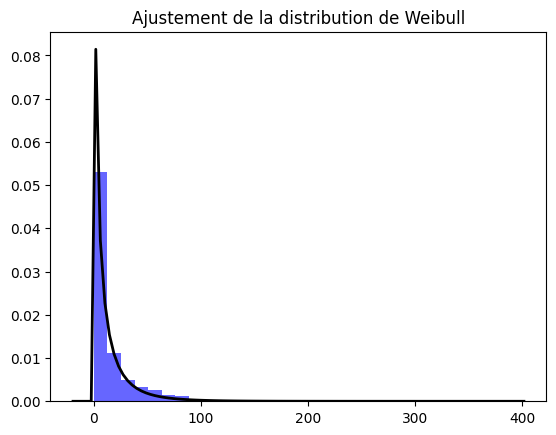

In [85]:
plt.hist(vec_vitaminC, bins=30, density=True, alpha=0.6, color='b')
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = st.weibull_min.pdf(x, shape, loc=loc, scale=scale)
plt.plot(x, p, 'k', linewidth=2)
plt.title('Ajustement de la distribution de Weibull')
plt.show()

In [86]:
mean, std = np.mean(vec_vitaminC), np.std(vec_vitaminC)

# Test de Kolmogorov-Smirnov
stat, p_value = st.kstest(vec_vitaminC, 'norm', args=(mean, std))
print(f"Test de Normalité: Statistique = {stat}, p-value = {p_value}")

Test de Normalité: Statistique = 0.28663787589533024, p-value = 2.8189234400077544e-68


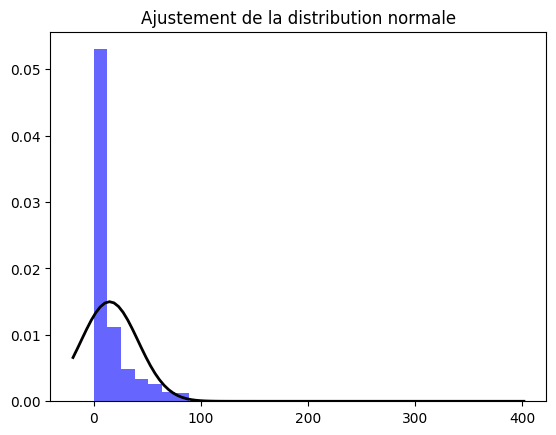

In [87]:
plt.hist(vec_vitaminC, bins=30, density=True, alpha=0.6, color='b')
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = st.norm.pdf(x, mean, std)
plt.plot(x, p, 'k', linewidth=2)
plt.title('Ajustement de la distribution normale')
plt.show()

#### Pour la Folate

In [88]:
vec_folate = df_indianfood["Folate (µg)"].dropna()
lambda_param = 1.0 / np.mean(vec_folate)


stat, p_value = st.kstest(vec_folate, 'expon', args=(lambda_param,))
print(f"Test d'Exponentielle: Statistique = {stat}, p-value = {p_value}")

Test d'Exponentielle: Statistique = 0.9119851308467423, p-value = 0.0


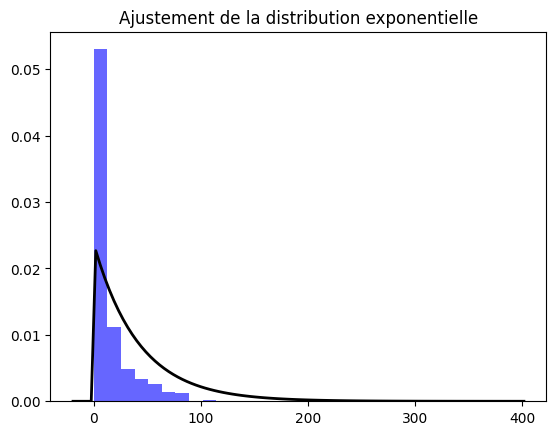

In [89]:
plt.hist(vec_vitaminC, bins=30, density=True, alpha=0.6, color='b')
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = st.expon.pdf(x, scale=1/lambda_param)
plt.plot(x, p, 'k', linewidth=2)
plt.title('Ajustement de la distribution exponentielle')
plt.show()

In [90]:
shape, loc, scale = st.gamma.fit(vec_folate)

stat, p_value = st.kstest(vec_folate, 'gamma', args=(shape, loc, scale))
print(f"Test de Gamma: Statistique = {stat}, p-value = {p_value}")

Test de Gamma: Statistique = 0.06837460256096961, p-value = 0.00031158088429536214


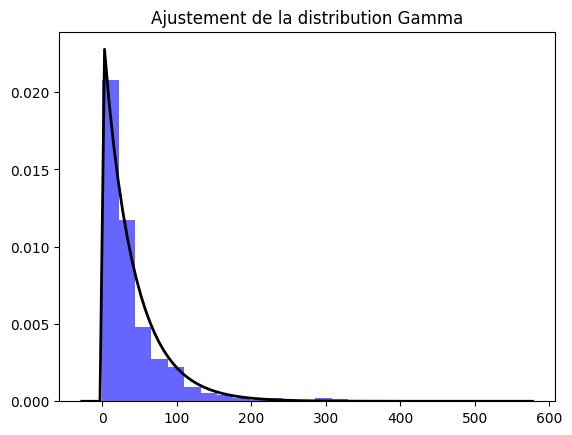

In [91]:
plt.hist(vec_folate, bins=25, density=True, alpha=0.6, color='b')
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = st.gamma.pdf(x, shape, loc=loc, scale=scale)
plt.plot(x, p, 'k', linewidth=2)
plt.title('Ajustement de la distribution Gamma')
plt.show()

In [92]:
shape, loc, scale = st.weibull_min.fit(vec_folate)

stat, p_value = st.kstest(vec_folate, 'weibull_min', args=(shape, loc, scale))
print(f"Test de Weibull: Statistique = {stat}, p-value = {p_value}")

Test de Weibull: Statistique = 0.056564319568467525, p-value = 0.004935365697623608


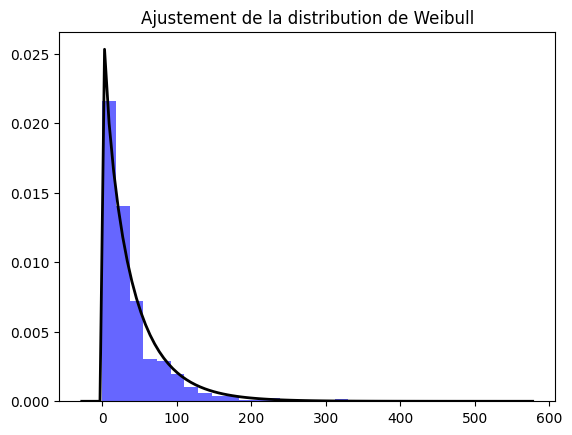

In [93]:
plt.hist(vec_folate, bins=30, density=True, alpha=0.6, color='b')
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = st.weibull_min.pdf(x, shape, loc=loc, scale=scale)
plt.plot(x, p, 'k', linewidth=2)
plt.title('Ajustement de la distribution de Weibull')
plt.show()

In [94]:
mean, std = np.mean(vec_folate), np.std(vec_folate)

# Test de Kolmogorov-Smirnov
stat, p_value = st.kstest(vec_folate, 'norm', args=(mean, std))
print(f"Test de Normalité: Statistique = {stat}, p-value = {p_value}")

Test de Normalité: Statistique = 0.2192888883416506, p-value = 7.779880323203713e-40


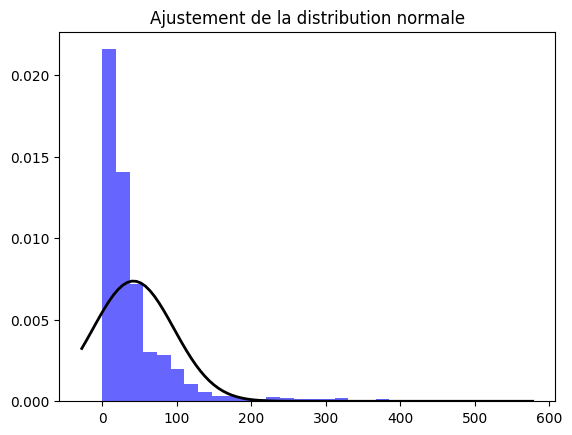

In [95]:
plt.hist(vec_folate, bins=30, density=True, alpha=0.6, color='b')
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = st.norm.pdf(x, mean, std)
plt.plot(x, p, 'k', linewidth=2)
plt.title('Ajustement de la distribution normale')
plt.show()

### Décision  de Nettoyage
Aucu  des testsa été concluant, on procède autrement

In [96]:
df_indianfood['Vitamin C (mg)'].fillna(0., inplace=True)
df_indianfood['Folate (µg)'].fillna(0., inplace=True)

/var/folders/kd/pckgp4pd2mz19vk2ljkn8xf00000gp/T/ipykernel_20741/266976790.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_indianfood['Vitamin C (mg)'].fillna(0., inplace=True)
/var/folders/kd/pckgp4pd2mz19vk2ljkn8xf00000gp/T/ipykernel_20741/266976790.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting value

In [97]:
df_indianfood.isna().sum()

Dish Name            0
Calories (kcal)      0
Carbohydrates (g)    0
Protein (g)          0
Fats (g)             0
Free Sugar (g)       0
Fibre (g)            0
Sodium (mg)          0
Calcium (mg)         0
Iron (mg)            0
Vitamin C (mg)       0
Folate (µg)          0
dtype: int64

In [98]:
df_indianfood.isnull().sum()

Dish Name            0
Calories (kcal)      0
Carbohydrates (g)    0
Protein (g)          0
Fats (g)             0
Free Sugar (g)       0
Fibre (g)            0
Sodium (mg)          0
Calcium (mg)         0
Iron (mg)            0
Vitamin C (mg)       0
Folate (µg)          0
dtype: int64

les données sont propres.

## Visualisation des donnnées

In [99]:
df_indianfood.columns.tolist()

['Dish Name',
 'Calories (kcal)',
 'Carbohydrates (g)',
 'Protein (g)',
 'Fats (g)',
 'Free Sugar (g)',
 'Fibre (g)',
 'Sodium (mg)',
 'Calcium (mg)',
 'Iron (mg)',
 'Vitamin C (mg)',
 'Folate (µg)']

In [100]:
len(df_indianfood['Dish Name'].unique())

1014

Les noms sont tous différents, à voir s'il existe des noms proches entre eux.

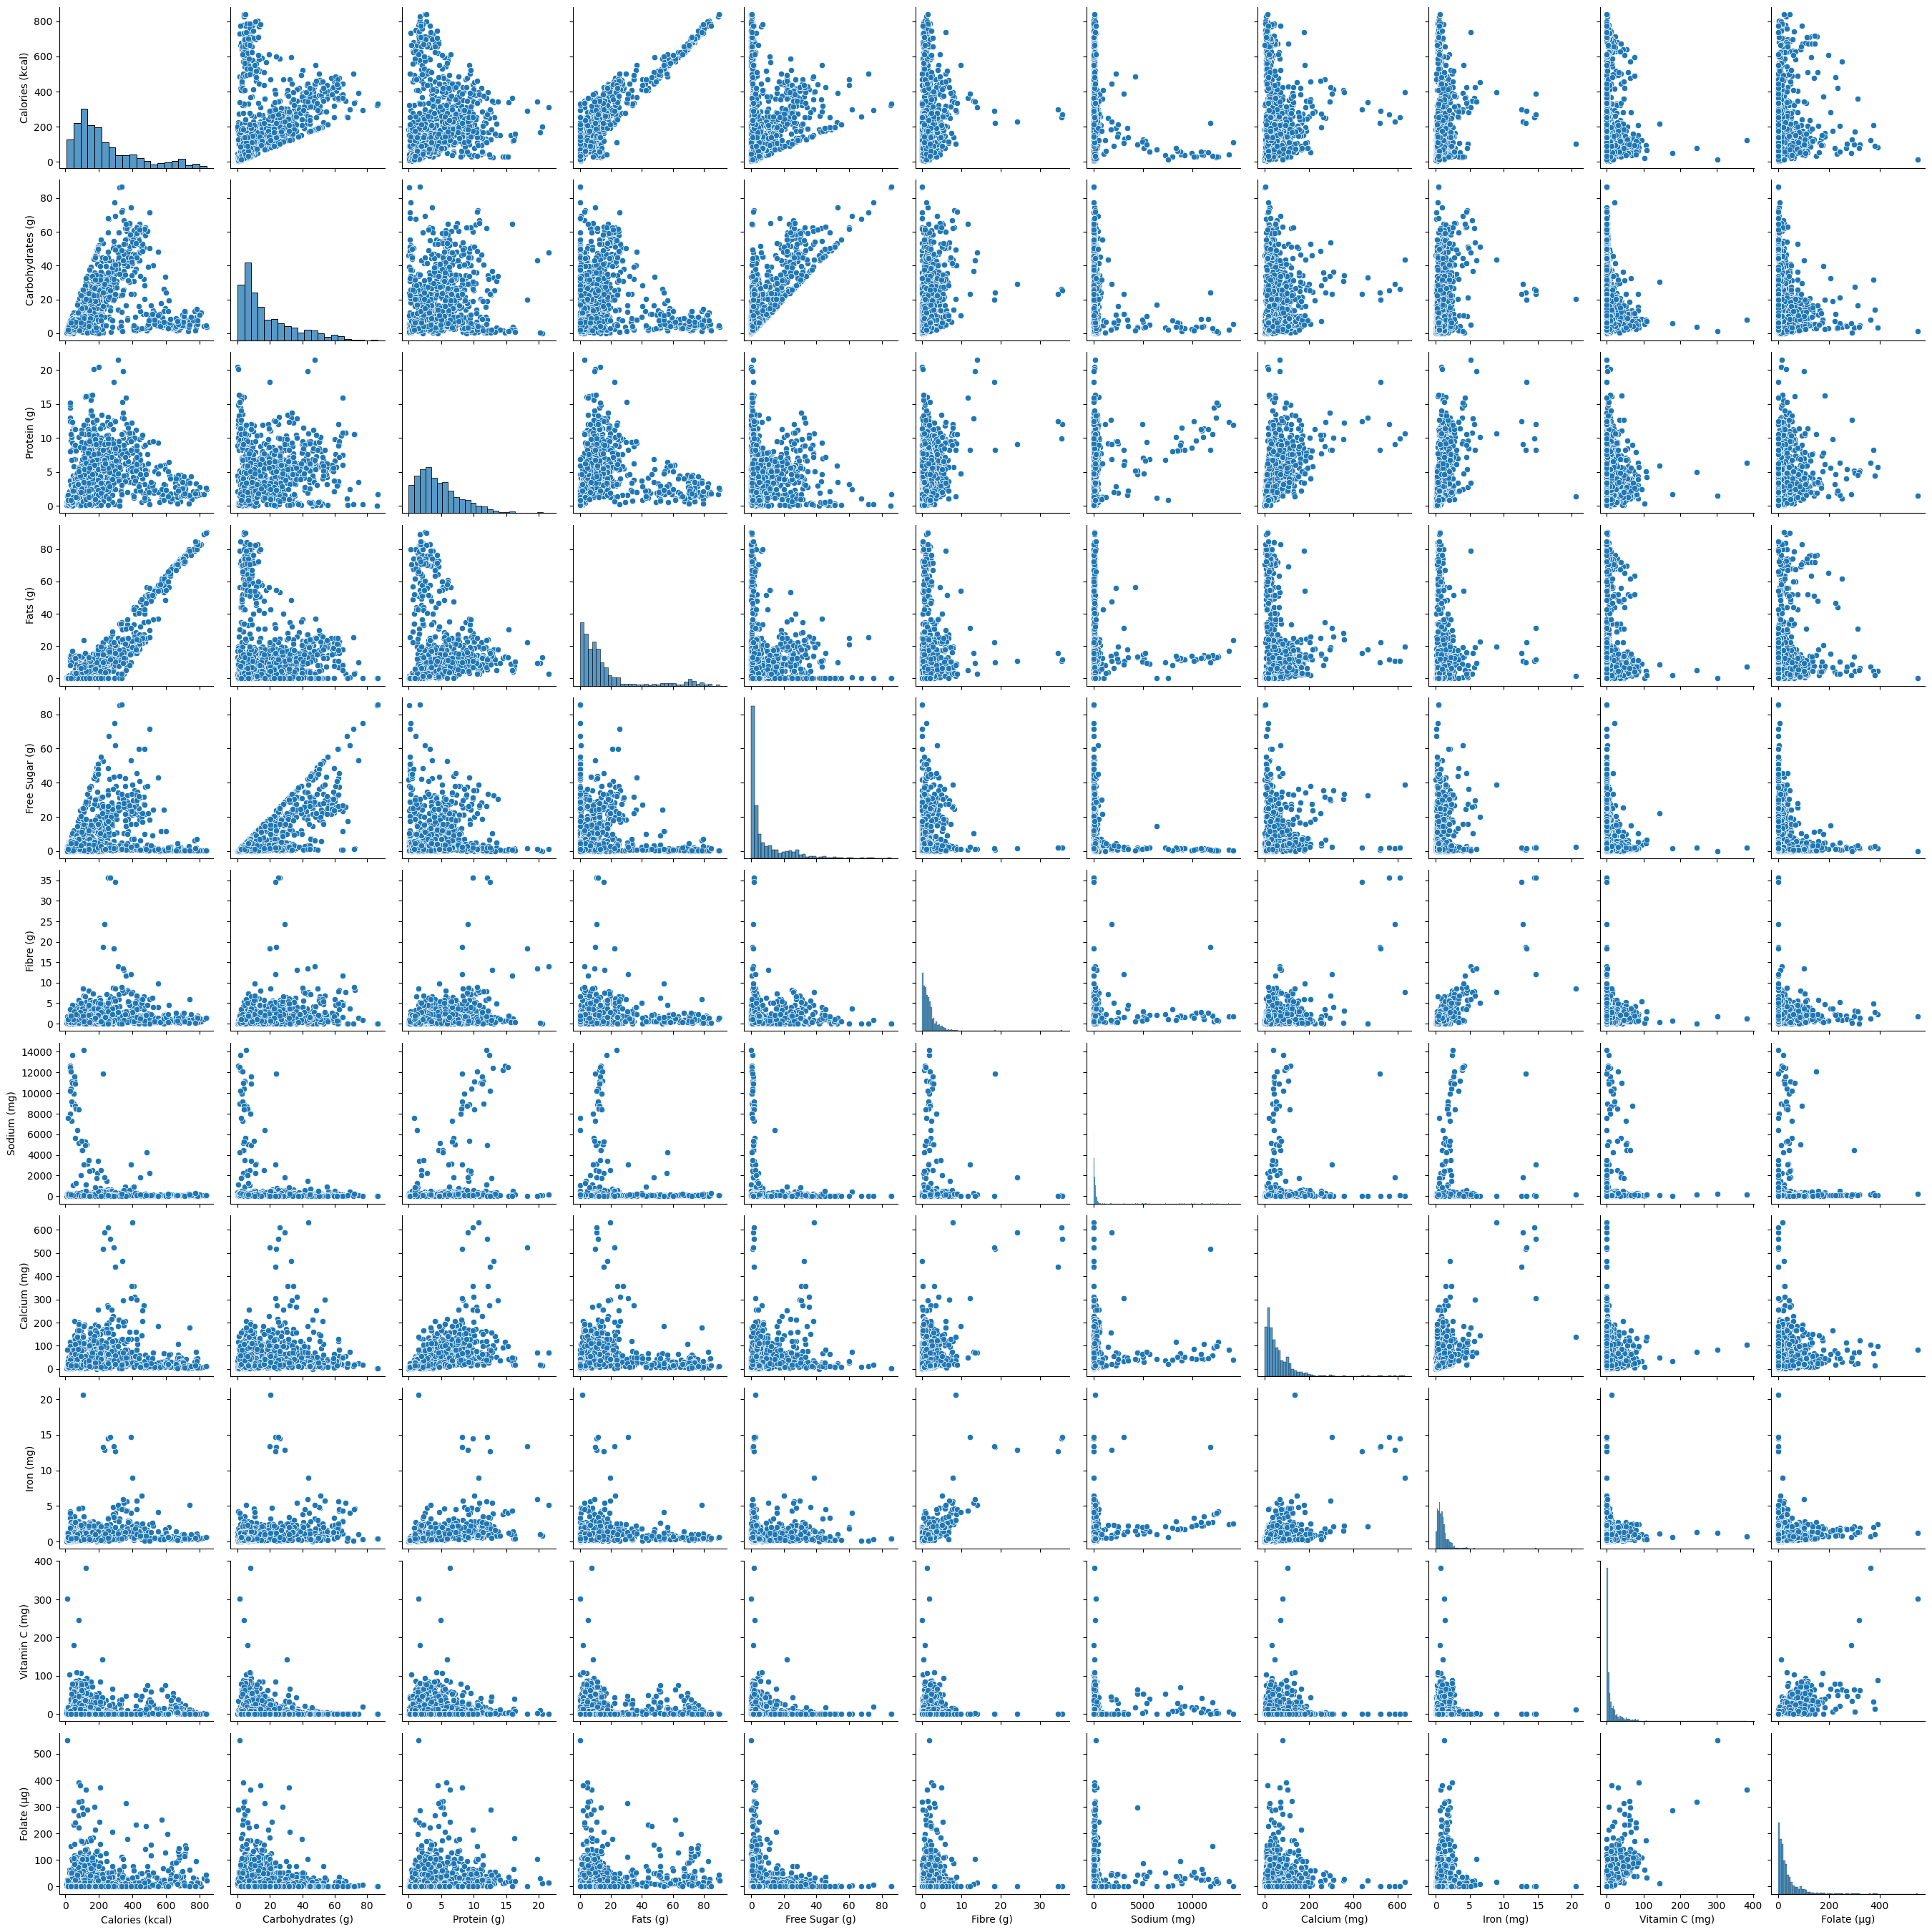

In [101]:
sns.pairplot(df_indianfood)
plt.show()

In [114]:
variables=df_indianfood.columns.tolist()
variables.remove('Dish Name')

couleurs = {
    'Calories (kcal)': '#e63946',      # Rouge foncé pour l'énergie
    'Carbohydrates (g)': '#f1faee',    # Vert menthe pour les glucides
    'Protein (g)': '#a8dadc',          # Bleu turquoise pour les protéines
    'Fats (g)': '#457b9d',             # Bleu pétrole pour les graisses
    'Free Sugar (g)': '#f4a261',       # Orange pêche pour les sucres libres
    'Fibre (g)': '#2a9d8f',            # Vert émeraude pour les fibres
    'Sodium (mg)': '#e9c46a',          # Jaune moutarde pour le sodium
    'Calcium (mg)': '#f4a261',         # Orange pêche pour le calcium
    'Iron (mg)': '#e76f51',            # Rouge brique pour le fer
    'Vitamin C (mg)': '#264653',       # Bleu nuit pour la vitamine C
    'Folate (µg)': '#2a9d8f'           # Vert émeraude pour le folate
}

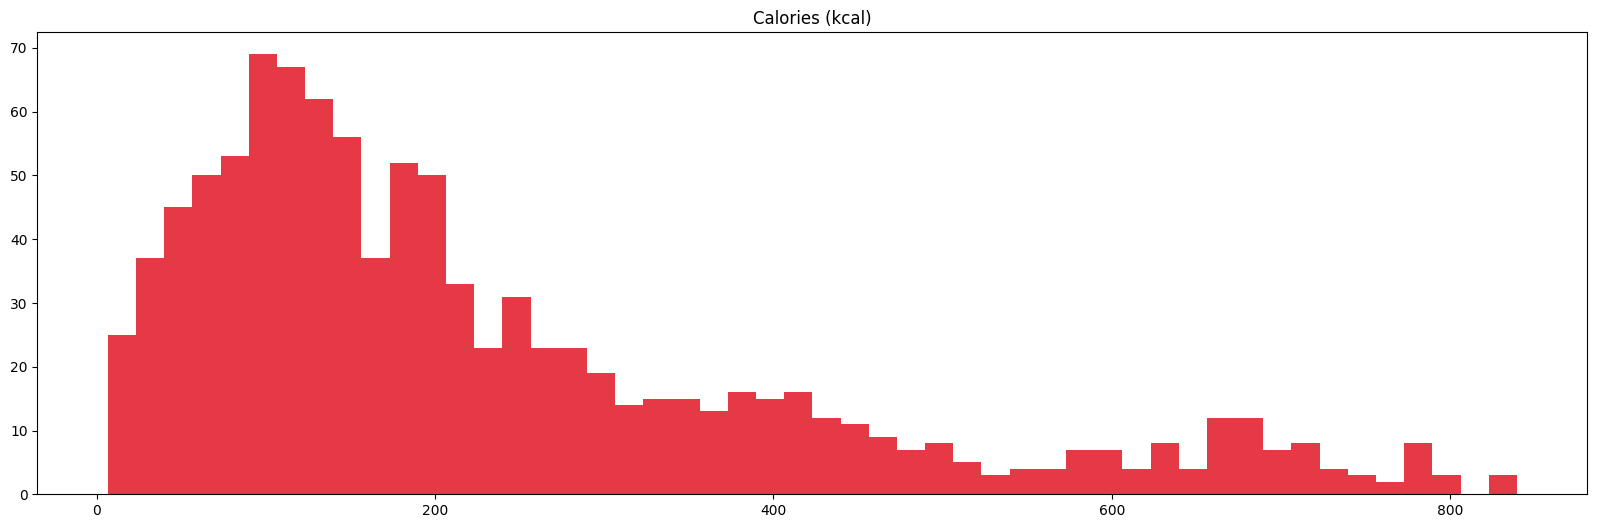

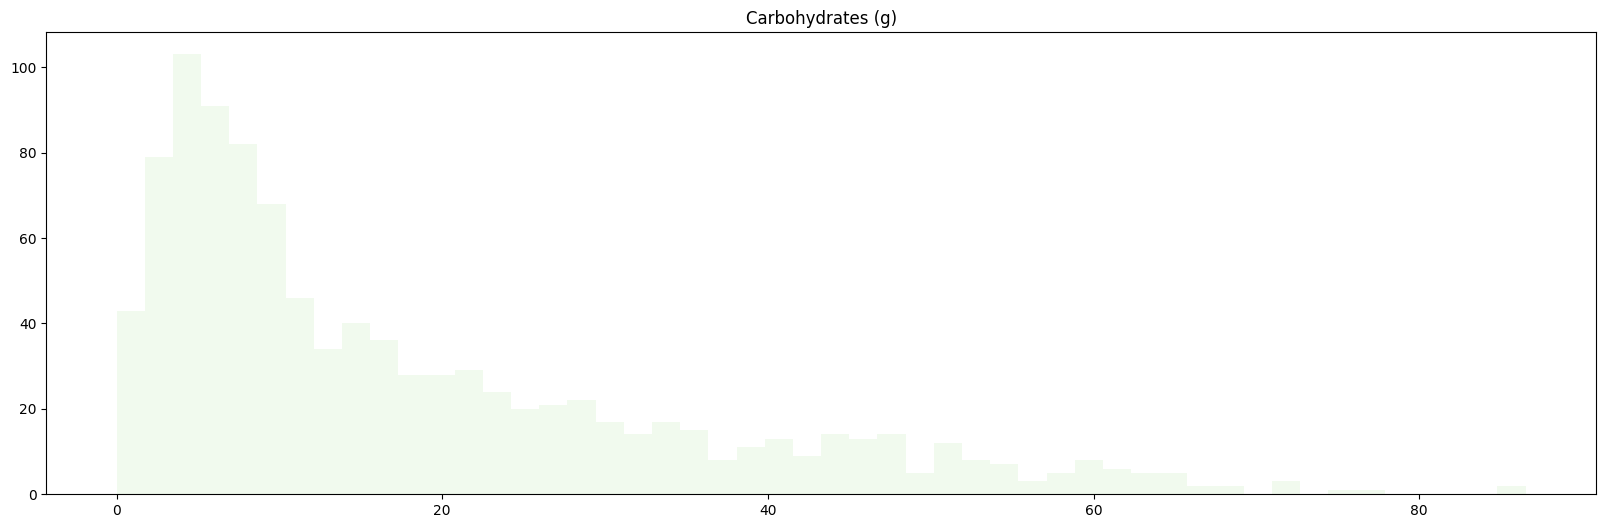

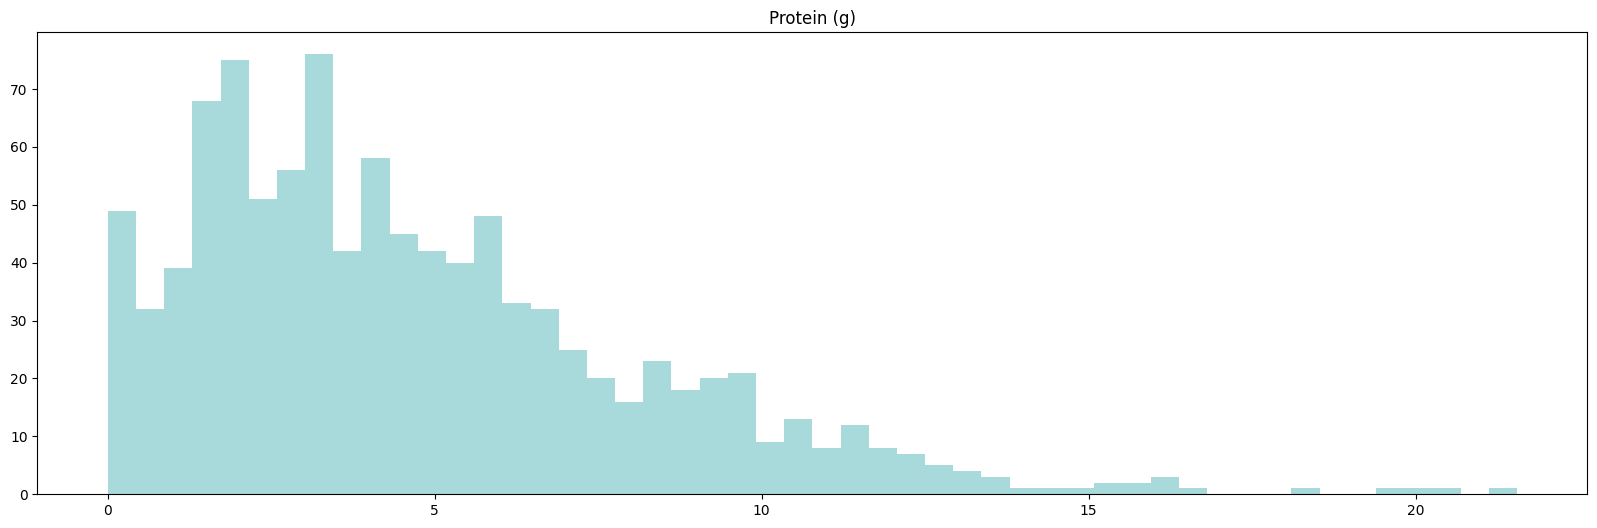

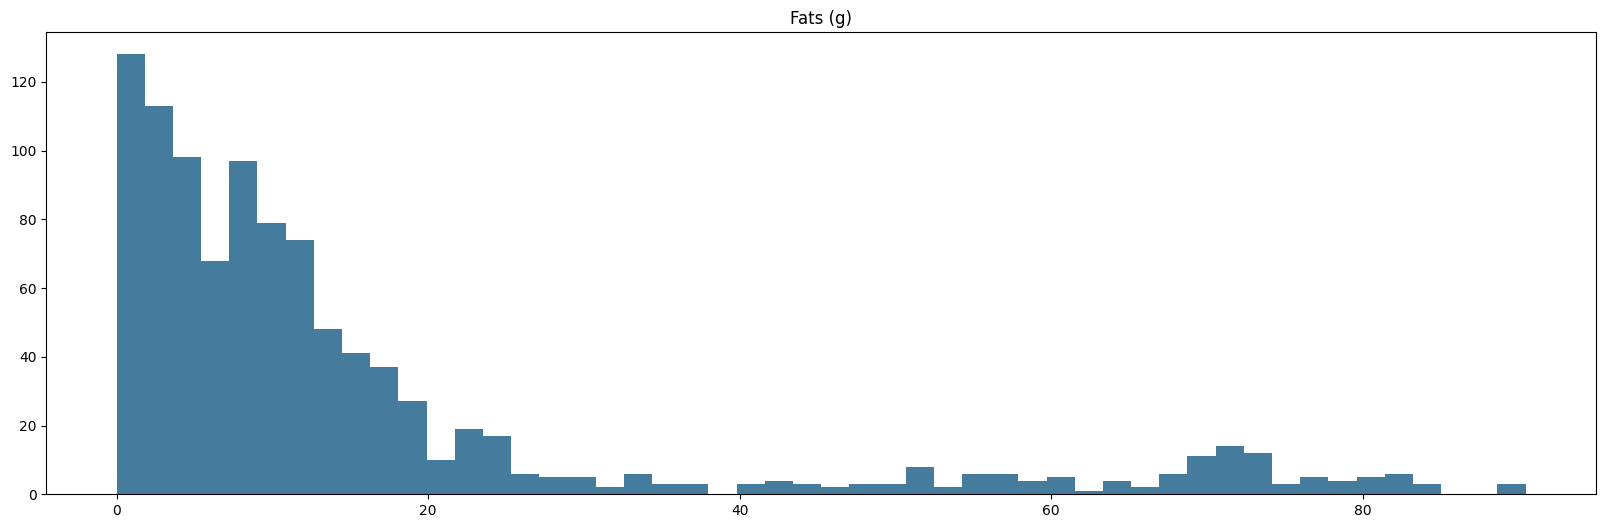

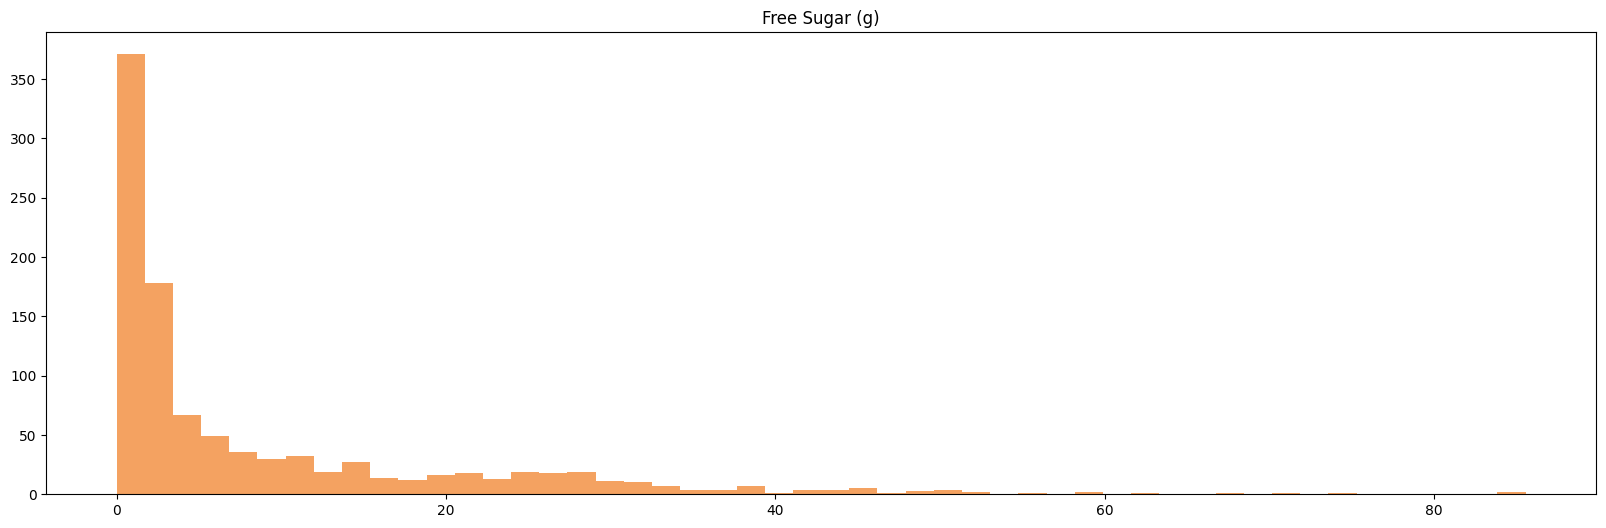

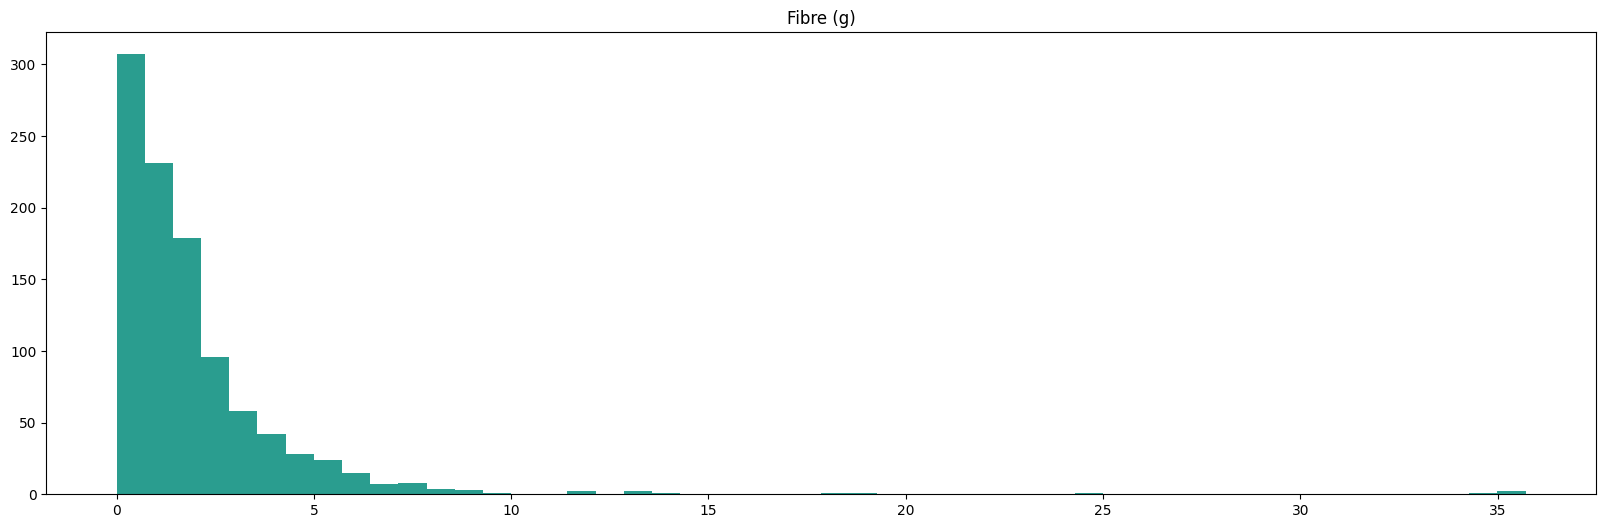

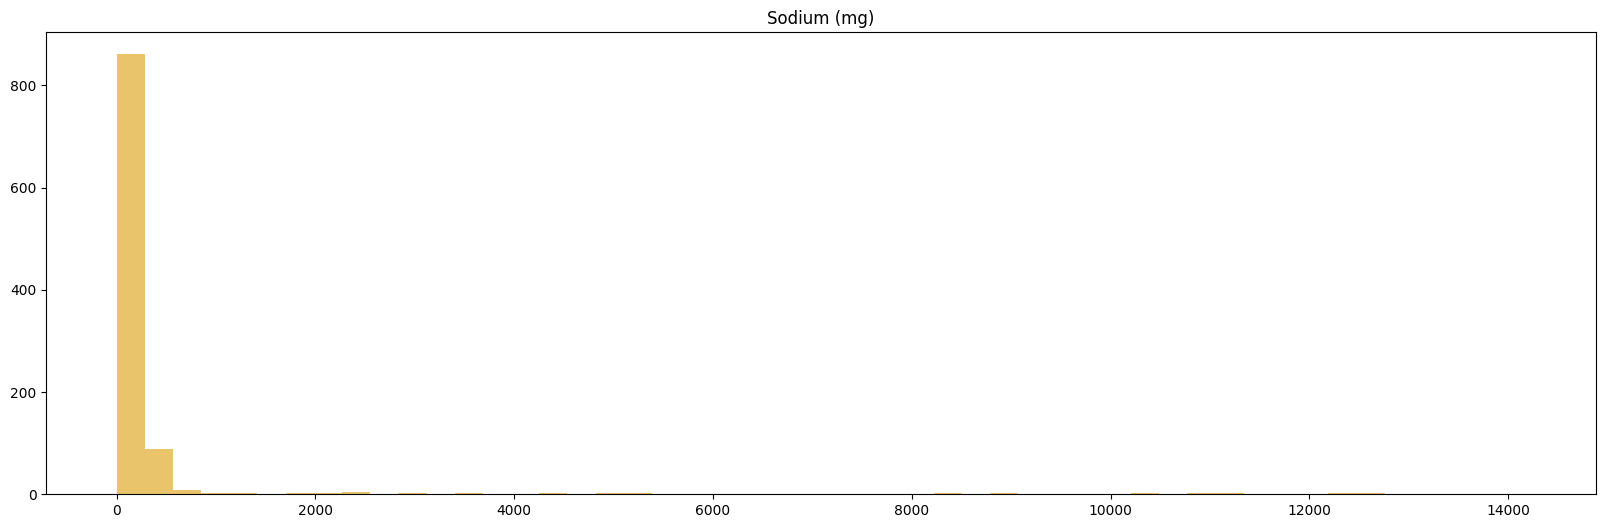

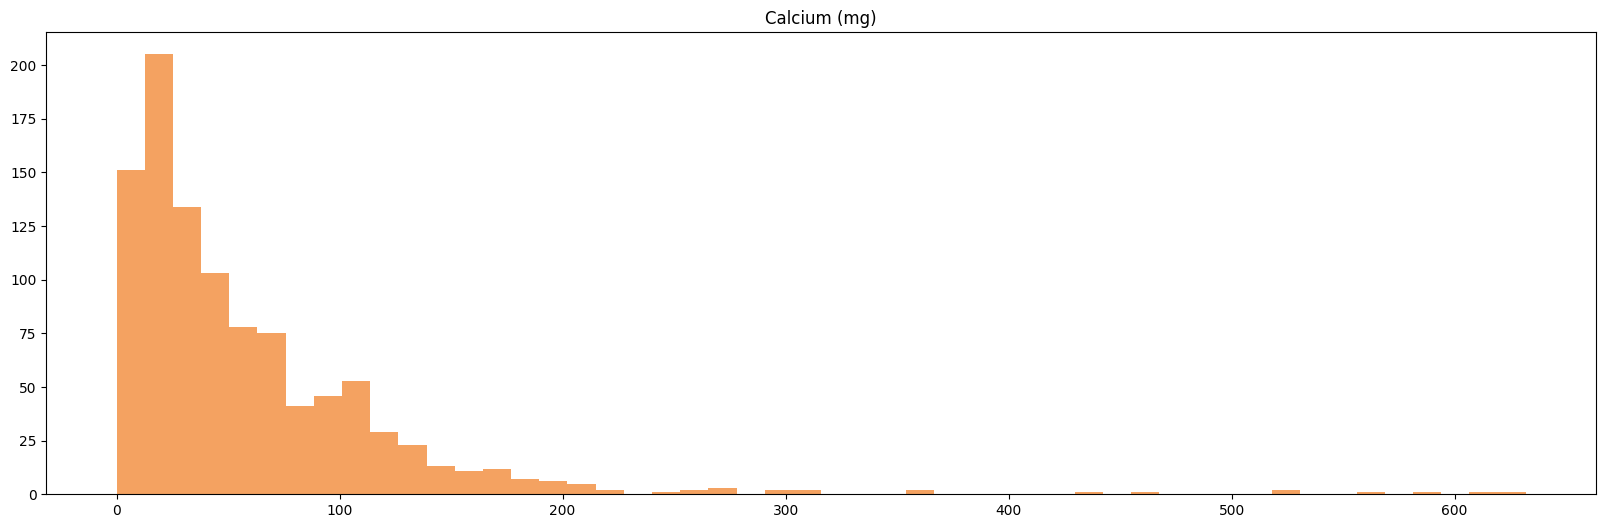

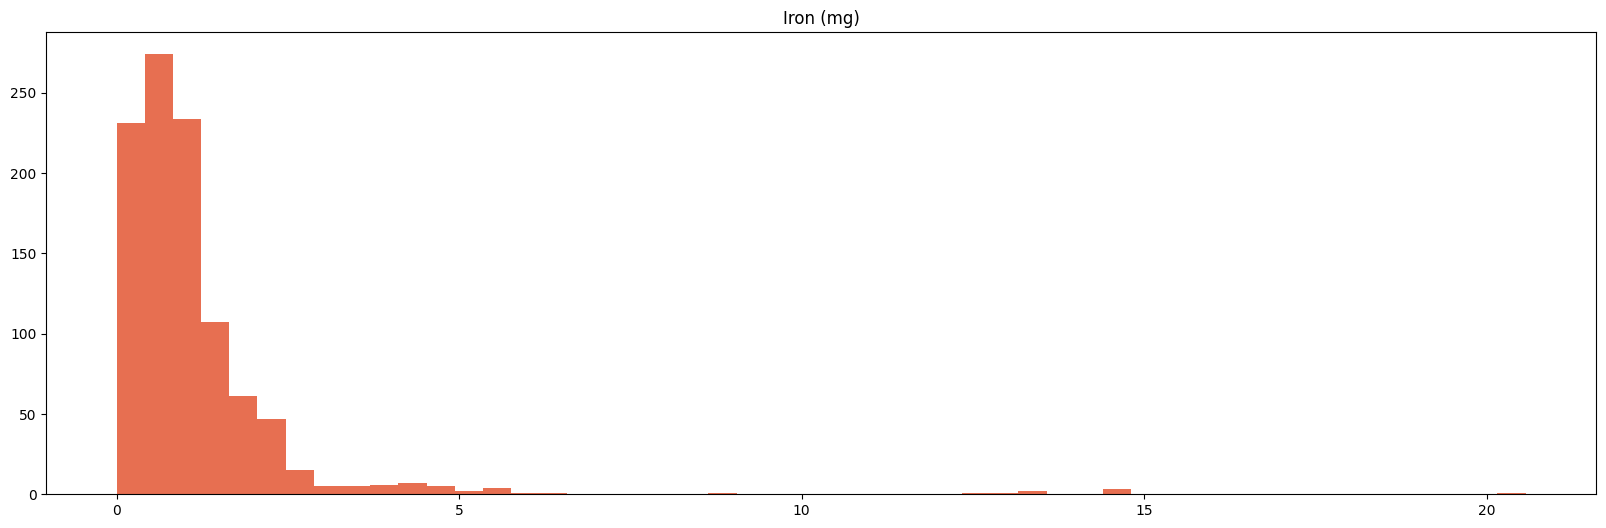

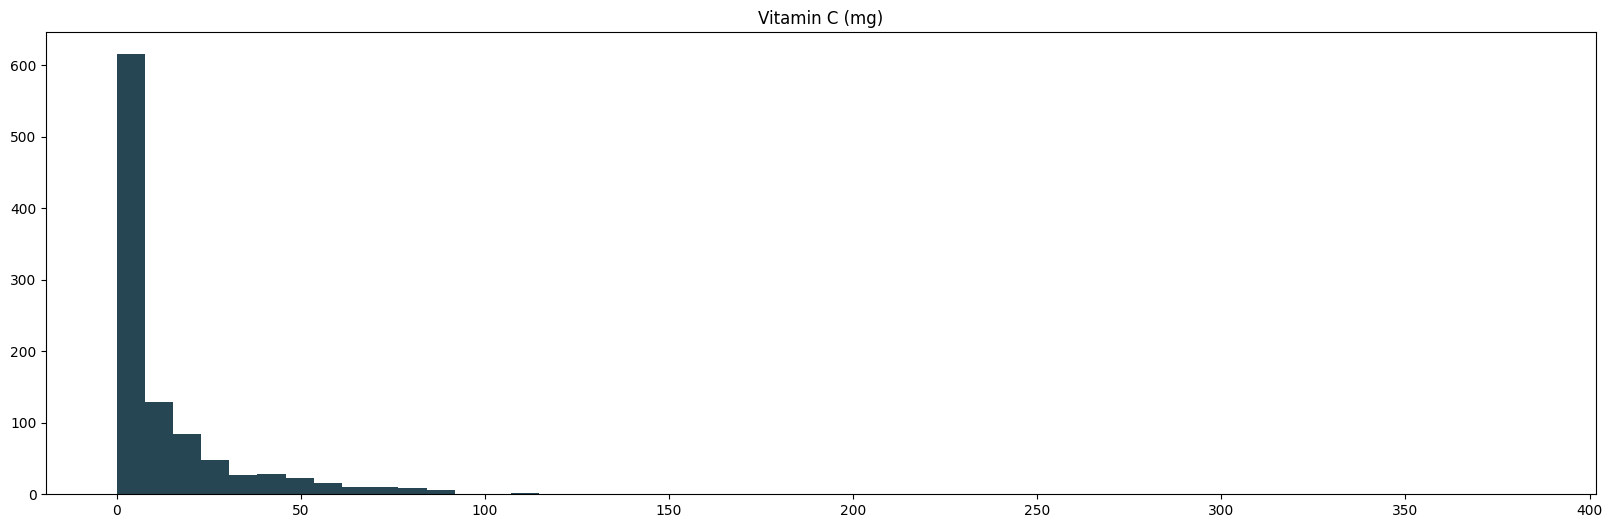

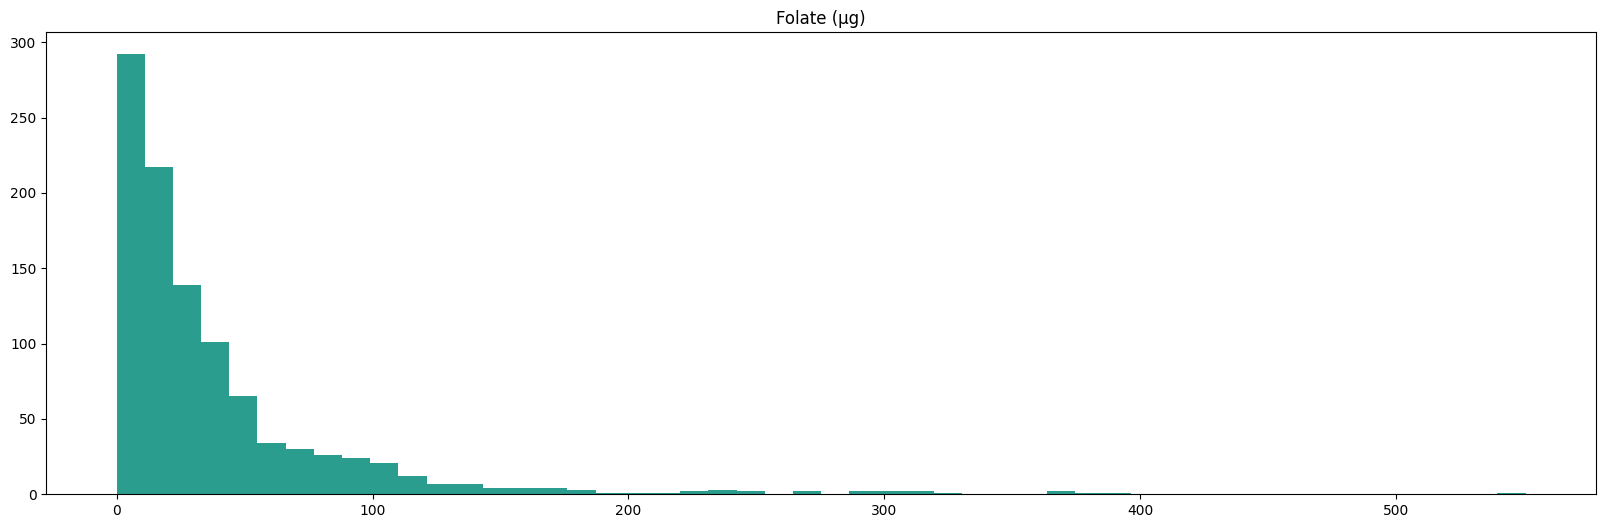

In [106]:
for var in variables:
    plt.figure(figsize=(20,6))
    plt.hist(df_indianfood[var], color=couleurs[var],bins=50)
    plt.title(f'{var}')

plt.show()

## Recherche de corrélation entre variables

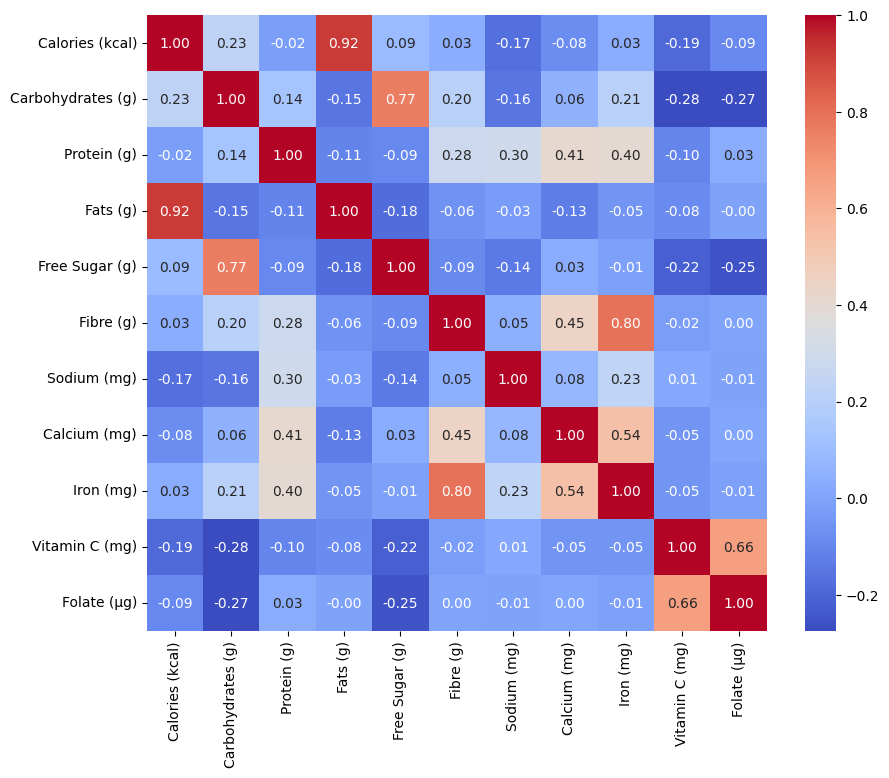

In [104]:
df_indianfoodbis=df_indianfood[variables]

matrice_indianfood=df_indianfoodbis.corr()

plt.figure(figsize=(10,8))
sns.heatmap(matrice_indianfood, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

## Tests Statistiques sur les autres variables

In [115]:
autres_variables=variables
autres_variables.remove('Vitamin C (mg)')
autres_variables.remove('Folate (µg)')

In [124]:
for var in autres_variables:
    vec = df_indianfood[var]
    print(f'Tests suur {var}')
    print(" ")

    #Test de loi Exponentielle
    lambda_param = 1.0/np.mean(vec)
    stat, p_value=st.kstest(vec, 'expon', args=(lambda_param,))
    print(f"Test d'Exponentielle : Statistique = {stat}, p-value={p_value}")
    print(" ")

    #Test de loi de Gamma
    shape, loc, scale = st.gamma.fit(vec)
    stat, p_value = st.kstest(vec, 'gamma', args=(shape, loc, scale))
    print(f"Test de Gamma : Statistique={stat}, p-value={p_value}")
    print(" ")

    #Test de loi de Weibull
    shape, loc, scale = st.weibull_min.fit(vec)
    stat, p_value = st.kstest(vec, 'weibull_min', args=(shape, loc, scale))
    print(f"Test de Weibull : Statistique = {stat}, p-value = {p_value}")
    print(" ")
    print(" ")

Tests suur Calories (kcal)
 
Test d'Exponentielle : Statistique = 0.9986473933102817, p-value=0.0
 
Test de Gamma : Statistique=0.049959836520266254, p-value=0.012231501859738526
 
Test de Weibull : Statistique = 0.058280150507088235, p-value = 0.0019543532432530013
 
 
Tests suur Carbohydrates (g)
 
Test d'Exponentielle : Statistique = 0.8567674907032871, p-value=0.0
 
Test de Gamma : Statistique=0.0615308377147889, p-value=0.0008842223346919339
 
Test de Weibull : Statistique = 0.062254497932549335, p-value = 0.0007367796572624579
 
 
Tests suur Protein (g)
 
Test d'Exponentielle : Statistique = 0.6092935311950558, p-value=0.0
 
Test de Gamma : Statistique=0.022247801294110303, p-value=0.6884928633828931
 
Test de Weibull : Statistique = 0.024717418813595265, p-value = 0.5567910878580741
 
 
Tests suur Fats (g)
 
Test d'Exponentielle : Statistique = 0.7479038977564592, p-value=0.0
 
Test de Gamma : Statistique=0.08440661599500354, p-value=9.841700270315565e-07
 
Test de Weibull : Sta

Toutes les p-values sont extrêmement faibles, les tests nous font rejeter les hypothèses comme quoi les variables suivraient une loi Gamma, Weibull ou Exponentielle

## Tests de la loi normale

In [125]:
for var in variables:
    vec = df_indianfood[var]
    print(f'Test sur {var}')
    print(" ")
    mean, std = np.mean(vec), np.std(vec)

    stat, p_value = st.kstest(vec, 'norm', args=(mean,std))
    print(f'Test de Normalité : Statistique : {stat}, p-value : {p_value}')
    print(' ')
    print(' ')

Test sur Calories (kcal)
 
Test de Normalité : Statistique : 0.15501829584527926, p-value : 9.572416744788247e-22
 
 
Test sur Carbohydrates (g)
 
Test de Normalité : Statistique : 0.15550861009370381, p-value : 7.003939549152501e-22
 
 
Test sur Protein (g)
 
Test de Normalité : Statistique : 0.09376118684832413, p-value : 3.292387348088734e-08
 
 
Test sur Fats (g)
 
Test de Normalité : Statistique : 0.23880957996314633, p-value : 2.2706460920349585e-51
 
 
Test sur Free Sugar (g)
 
Test de Normalité : Statistique : 0.23783686108487578, p-value : 5.963576382517772e-51
 
 
Test sur Fibre (g)
 
Test de Normalité : Statistique : 0.23934435461421577, p-value : 1.3329990165476744e-51
 
 
Test sur Sodium (mg)
 
Test de Normalité : Statistique : 0.42947386783267755, p-value : 2.2061478801787753e-170
 
 
Test sur Calcium (mg)
 
Test de Normalité : Statistique : 0.19060560838803922, p-value : 9.791535824863876e-33
 
 
Test sur Iron (mg)
 
Test de Normalité : Statistique : 0.23179133582313124,